In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [2]:
df = pd.read_csv("../data/raw/inventory_data.csv")

df.head()

,Date,Product_Name,Category,Units_Sold,Inventory_Level,Price,Promotion,Supplier,Lead_Time,Revenue
0,2023-03-07,Lotion,Personal Care,41,96,780.63,Yes,Prime Distribution,12,32005.83
1,2023-01-29,Phone,Electronics,22,495,1521.17,Yes,ABC Suppliers,4,33465.74
2,2024-04-28,Mouse,Electronics,46,199,485.75,Yes,ABC Suppliers,3,22344.50
3,2023-10-20,Butter,Groceries,25,464,1042.25,Yes,Smart Wholesale,14,26056.25
4,2023-04-19,Conditioner,Personal Care,42,293,939.73,Yes,Prime Distribution,5,39468.66


In [3]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (10000, 10)


In [22]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             10000 non-null  datetime64[us]
 1   Product_Name     10000 non-null  str           
 2   Category         10000 non-null  str           
 3   Units_Sold       10000 non-null  int64         
 4   Inventory_Level  10000 non-null  int64         
 5   Price            10000 non-null  float64       
 6   Promotion        10000 non-null  str           
 7   Supplier         10000 non-null  str           
 8   Lead_Time        10000 non-null  int64         
 9   Revenue          10000 non-null  float64       
 10  Year             10000 non-null  int32         
 11  Month            10000 non-null  str           
 12  Month_Number     10000 non-null  int32         
 13  Day              10000 non-null  int32         
 14  Day_of_Week      10000 non-null  str           
 1

Index(['Date', 'Product_Name', 'Category', 'Units_Sold', 'Inventory_Level',
       'Price', 'Promotion', 'Supplier', 'Lead_Time', 'Revenue', 'Year',
       'Month', 'Month_Number', 'Day', 'Day_of_Week', 'Quarter'],
      dtype='str')

In [23]:
# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Create new features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Month_Number"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.day_name()
df["Quarter"] = df["Date"].dt.quarter

# Verify
df.head()

,Date,Product_Name,Category,Units_Sold,Inventory_Level,Price,Promotion,Supplier,Lead_Time,Revenue,Year,Month,Month_Number,Day,Day_of_Week,Quarter
0,2023-03-07,Lotion,Personal Care,41,96,780.63,Yes,Prime Distribution,12,32005.83,2023,March,3,7,Tuesday,1
1,2023-01-29,Phone,Electronics,22,495,1521.17,Yes,ABC Suppliers,4,33465.74,2023,January,1,29,Sunday,1
2,2024-04-28,Mouse,Electronics,46,199,485.75,Yes,ABC Suppliers,3,22344.50,2024,April,4,28,Sunday,2
3,2023-10-20,Butter,Groceries,25,464,1042.25,Yes,Smart Wholesale,14,26056.25,2023,October,10,20,Friday,4
4,2023-04-19,Conditioner,Personal Care,42,293,939.73,Yes,Prime Distribution,5,39468.66,2023,April,4,19,Wednesday,2


In [20]:
df.isnull().sum()

Date               0
Product_Name       0
Category           0
Units_Sold         0
Inventory_Level    0
Price              0
Promotion          0
Supplier           0
Lead_Time          0
Revenue            0
Year               0
Month              0
Month_Number       0
Day                0
Day_of_Week        0
Quarter            0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             10000 non-null  datetime64[us]
 1   Product_Name     10000 non-null  str           
 2   Category         10000 non-null  str           
 3   Units_Sold       10000 non-null  int64         
 4   Inventory_Level  10000 non-null  int64         
 5   Price            10000 non-null  float64       
 6   Promotion        10000 non-null  str           
 7   Supplier         10000 non-null  str           
 8   Lead_Time        10000 non-null  int64         
 9   Revenue          10000 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(4)
memory usage: 1.1 MB


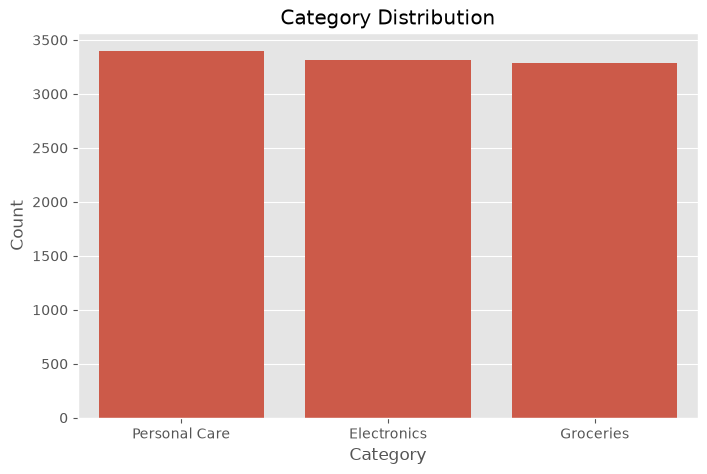

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index
)

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

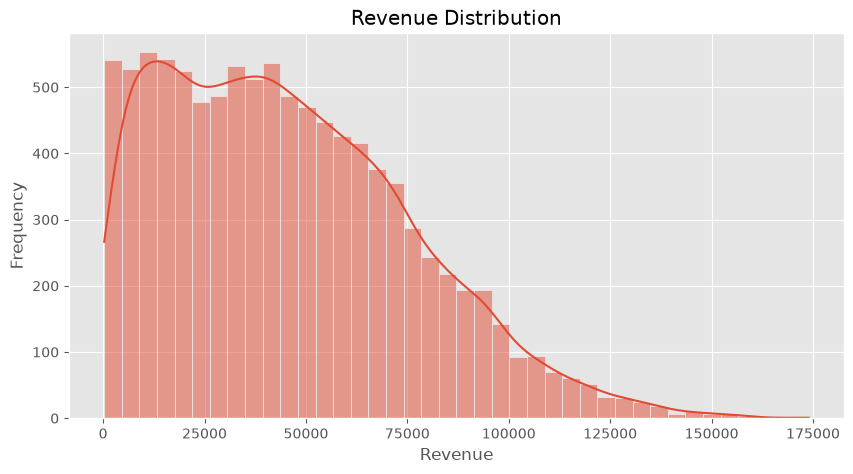

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Revenue",
    bins=40,
    kde=True
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

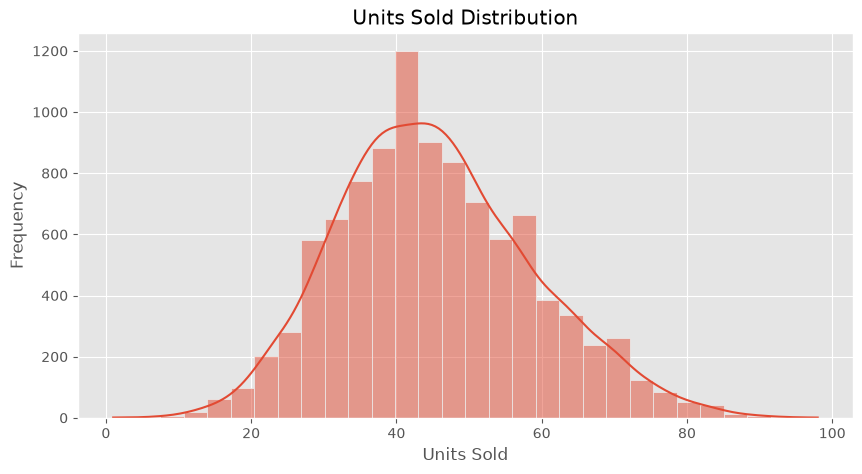

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Units_Sold",
    bins=30,
    kde=True
)

plt.title("Units Sold Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

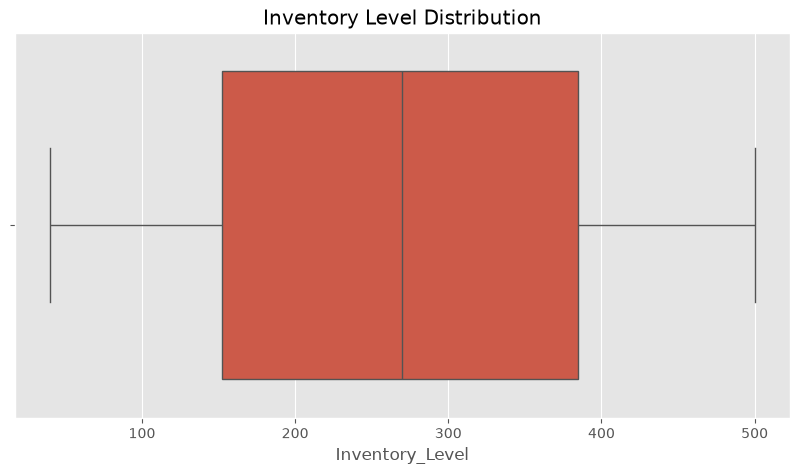

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Inventory_Level"]
)

plt.title("Inventory Level Distribution")

plt.show()

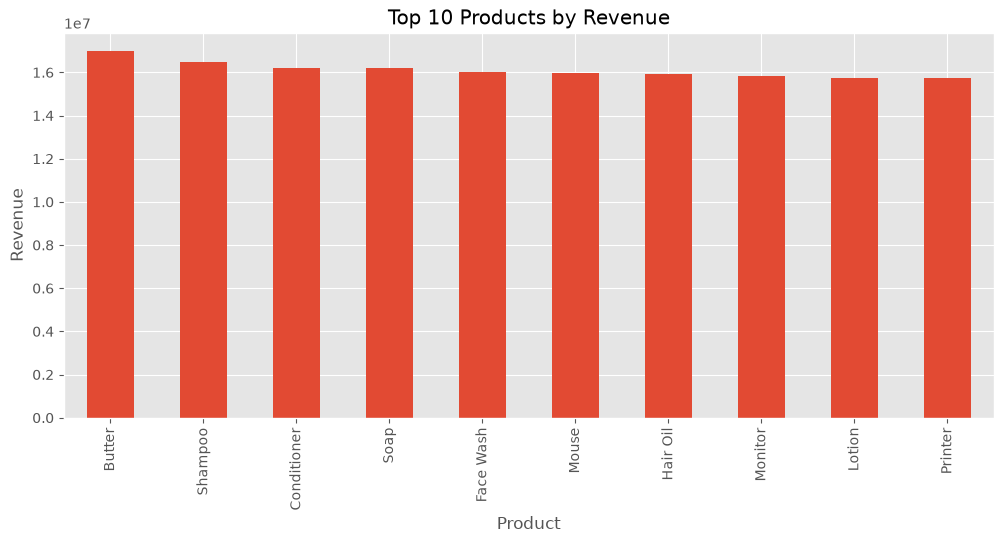

In [14]:
top_products = (
    df.groupby("Product_Name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

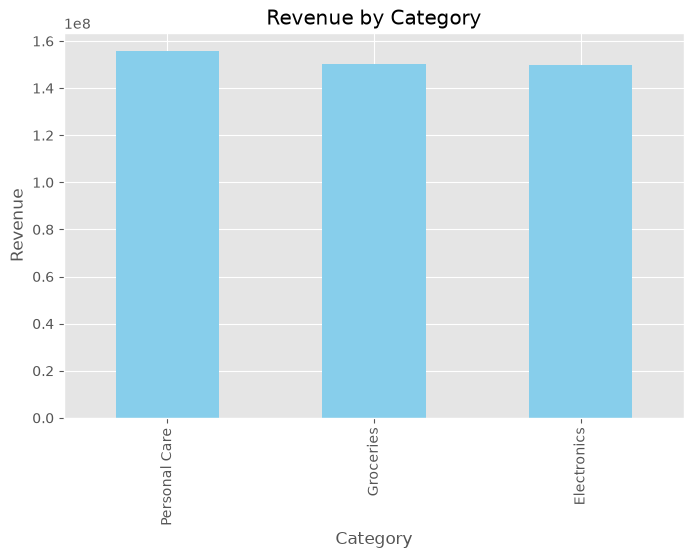

In [15]:
category_revenue = (
    df.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_revenue.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

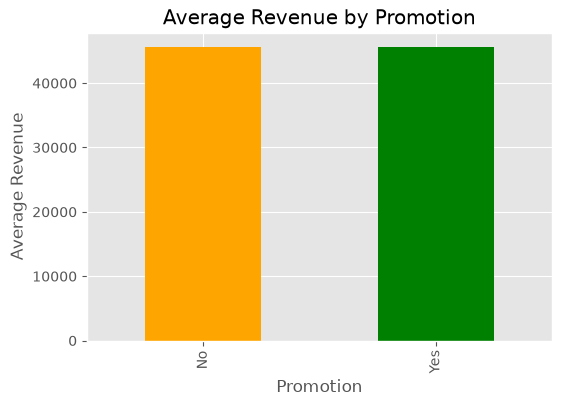

In [16]:
promotion_revenue = (
    df.groupby("Promotion")["Revenue"]
    .mean()
)

plt.figure(figsize=(6,4))

promotion_revenue.plot(
    kind="bar",
    color=["orange", "green"]
)

plt.title("Average Revenue by Promotion")
plt.ylabel("Average Revenue")

plt.show()

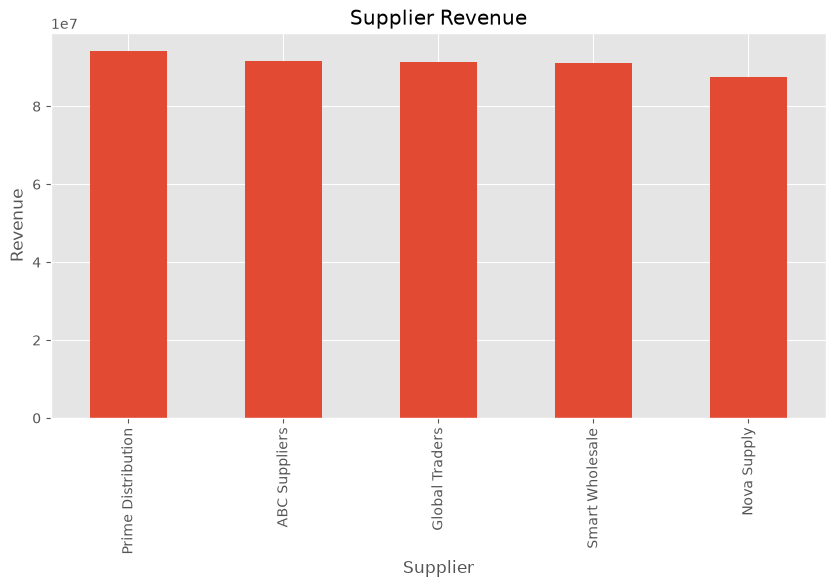

In [17]:
supplier_revenue = (
    df.groupby("Supplier")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

supplier_revenue.plot(
    kind="bar"
)

plt.title("Supplier Revenue")
plt.xlabel("Supplier")
plt.ylabel("Revenue")

plt.show()

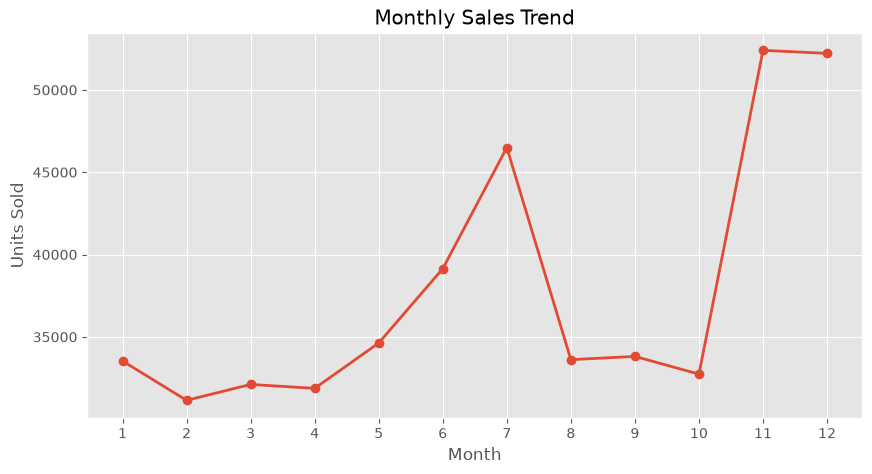

In [24]:
monthly_sales = (
    df.groupby("Month_Number")["Units_Sold"]
      .sum()
)

plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

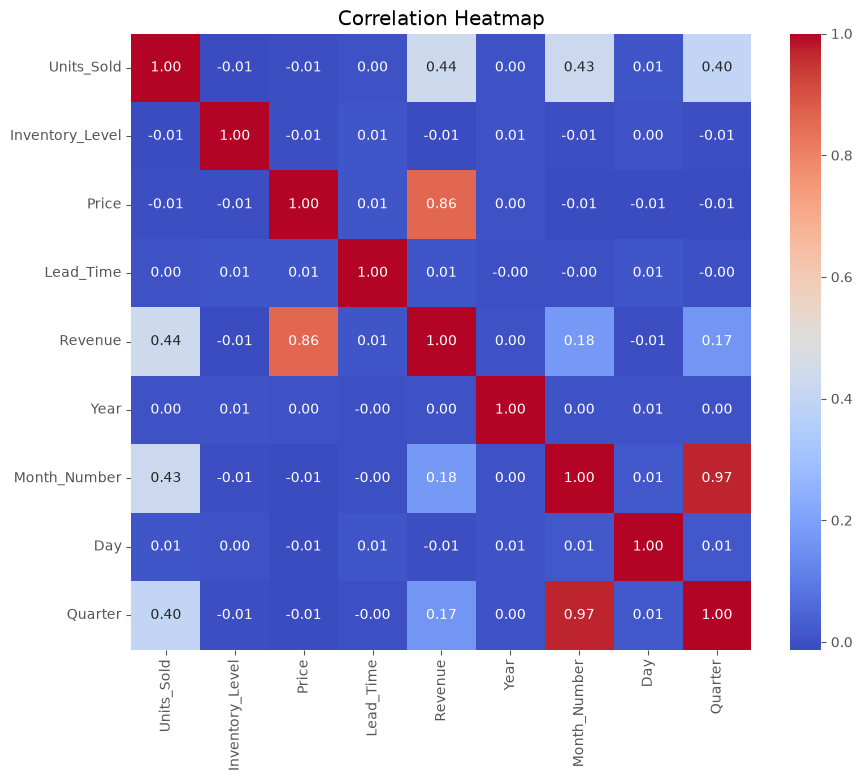

In [25]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [26]:
df.to_csv("../data/processed/clean_inventory_data.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
